# OTel Release vs Energy per Request

This notebook compares **energy/request** across OTel Demo releases with:
- x-axis: OTel release
- y-axis: Energy per request (J/request)
- series: low, medium, high
- separate panels: workstation (`eoan_`) and EC2 (`julian_`)

Data source: each experiment folder's `runs_comparison.html` (`const data = {...}` payload).

In [6]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 80)

RUNS_ROOT = Path('../final-runs/experiment-runs-with-attribution')

# Folder name -> release label
RELEASE_MAP = {
    'otel-demo-1.12.0': '1.12.0',
    'otel-demo-2.0.0': '2.0.0',
    'otel-demo': '2.2.0',
}

RELEASE_ORDER = ['1.12.0', '2.0.0', '2.2.0']
WORKLOAD_ORDER = ['low', 'medium', 'high']
ENV_ORDER = ['workstation', 'ec2']

missing = [name for name in RELEASE_MAP if not (RUNS_ROOT / name).exists()]
if missing:
    raise FileNotFoundError(f'Missing release folders under {RUNS_ROOT}: {missing}')

RUNS_ROOT.resolve()

PosixPath('/Users/eoan/Sites/univaq/phd/energyAnalyser/controller/final-runs/experiment-runs-with-attribution')

In [7]:
def extract_json_object_after_marker(text: str, marker: str) -> dict:
    marker_idx = text.find(marker)
    if marker_idx < 0:
        raise ValueError(f'Marker not found: {marker}')

    start = text.find('{', marker_idx)
    if start < 0:
        raise ValueError('Could not find JSON object start after marker')

    depth = 0
    in_string = False
    escaped = False

    for i in range(start, len(text)):
        ch = text[i]

        if in_string:
            if escaped:
                escaped = False
            elif ch == '\\':
                escaped = True
            elif ch == '"':
                in_string = False
            continue

        if ch == '"':
            in_string = True
            continue

        if ch == '{':
            depth += 1
        elif ch == '}':
            depth -= 1
            if depth == 0:
                return json.loads(text[start:i + 1])

    raise ValueError('Could not find end of JSON object')

def environment_from_folder(name: str) -> str | None:
    if name.startswith('eoan_'):
        return 'workstation'
    if name.startswith('julian_'):
        return 'ec2'
    return None

rows = []

for folder_name, release in RELEASE_MAP.items():
    release_dir = RUNS_ROOT / folder_name

    for experiment_dir in sorted(release_dir.iterdir()):
        if not experiment_dir.is_dir():
            continue

        env = environment_from_folder(experiment_dir.name)
        if env is None:
            continue

        dashboard_path = experiment_dir / 'runs_comparison.html'
        if not dashboard_path.exists():
            continue

        html = dashboard_path.read_text(encoding='utf-8')
        payload = extract_json_object_after_marker(html, 'const data = ')

        for run in payload.get('runs', []):
            wl = str(run.get('workload_level', '')).lower()
            if wl not in WORKLOAD_ORDER:
                continue

            epr = run.get('energy_per_request')
            if epr is None:
                epr = run.get('meter_energy_per_request_joules')

            if epr is None:
                continue

            try:
                epr = float(epr)
            except (TypeError, ValueError):
                continue

            rows.append({
                'release': release,
                'environment': env,
                'workload_level': wl,
                'energy_per_request_j': epr,
                'experiment_folder': experiment_dir.name,
                'run_name': run.get('name', ''),
            })

df = pd.DataFrame(rows)
if df.empty:
    raise RuntimeError('No runs were parsed. Check folder paths and dashboard format.')

df['release'] = pd.Categorical(df['release'], categories=RELEASE_ORDER, ordered=True)
df['workload_level'] = pd.Categorical(df['workload_level'], categories=WORKLOAD_ORDER, ordered=True)
df['environment'] = pd.Categorical(df['environment'], categories=ENV_ORDER, ordered=True)

agg = (
    df.groupby(['environment', 'release', 'workload_level'], observed=True)
      .agg(
          mean_energy_per_request_j=('energy_per_request_j', 'mean'),
          std_energy_per_request_j=('energy_per_request_j', 'std'),
          n=('energy_per_request_j', 'size'),
      )
      .reset_index()
)

print('Parsed runs:', len(df))
print('Grouped rows:', len(agg))
agg.head(12)

Parsed runs: 90
Grouped rows: 18


,environment,release,workload_level,mean_energy_per_request_j,std_energy_per_request_j,n
0,workstation,1.12.0,low,0.002025,0.000069,5
1,workstation,1.12.0,medium,0.001184,0.000039,5
2,workstation,1.12.0,high,0.001075,0.000042,5
3,workstation,2.0.0,low,0.001948,0.000085,5
4,workstation,2.0.0,medium,0.001206,0.000026,5
5,workstation,2.0.0,high,0.001077,0.000023,5
6,workstation,2.2.0,low,0.002026,0.000065,5
7,workstation,2.2.0,medium,0.001212,0.000038,5
8,workstation,2.2.0,high,0.001055,0.000040,5
9,ec2,1.12.0,low,1.756969,0.020435,5


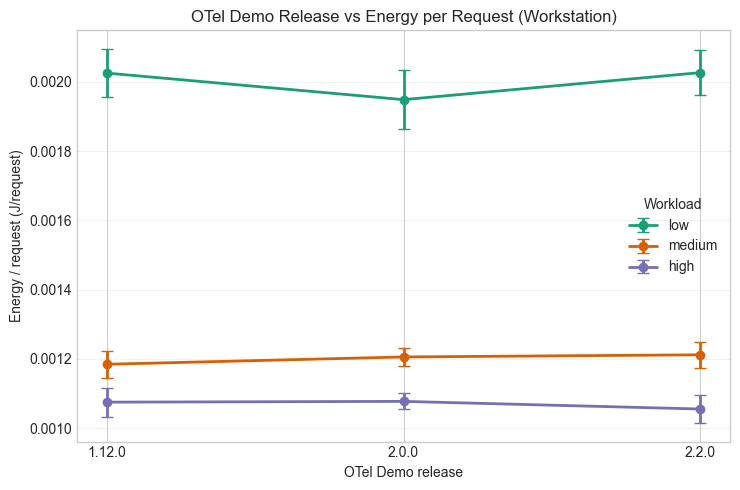

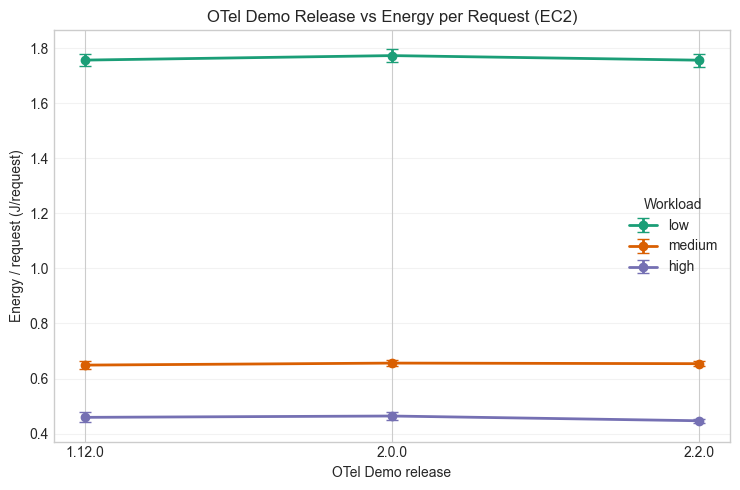

In [5]:
colors = {'low': '#1b9e77', 'medium': '#d95f02', 'high': '#7570b3'}

for env in ENV_ORDER:
    fig, ax = plt.subplots(figsize=(7.5, 5))
    env_data = agg[agg['environment'] == env].copy()

    for wl in WORKLOAD_ORDER:
        s = env_data[env_data['workload_level'] == wl].sort_values('release')
        if s.empty:
            continue

        y = s['mean_energy_per_request_j'].to_numpy()
        yerr = s['std_energy_per_request_j'].fillna(0).to_numpy()

        ax.errorbar(
            s['release'].astype(str),
            y,
            yerr=yerr,
            marker='o',
            capsize=4,
            linewidth=2,
            color=colors[wl],
            label=wl,
        )

    panel_name = 'Workstation' if env == 'workstation' else 'EC2'
    ax.set_title(f'OTel Demo Release vs Energy per Request ({panel_name})')
    ax.set_xlabel('OTel Demo release')
    ax.set_ylabel('Energy / request (J/request)')
    ax.grid(True, axis='y', alpha=0.25)
    ax.legend(title='Workload')

    fig.tight_layout()
    plt.show()

In [4]:
# Optional: compact table view used by the chart
table = agg.copy()
table['mean_energy_per_request_j'] = table['mean_energy_per_request_j'].round(6)
table['std_energy_per_request_j'] = table['std_energy_per_request_j'].round(6)
table.sort_values(['environment', 'workload_level', 'release']).reset_index(drop=True)

,environment,release,workload_level,mean_energy_per_request_j,std_energy_per_request_j,n
0,workstation,1.12.0,low,0.002025,0.000069,5
1,workstation,2.0.0,low,0.001948,0.000085,5
2,workstation,2.2.0,low,0.002026,0.000065,5
3,workstation,1.12.0,medium,0.001184,0.000039,5
4,workstation,2.0.0,medium,0.001206,0.000026,5
5,workstation,2.2.0,medium,0.001212,0.000038,5
6,workstation,1.12.0,high,0.001075,0.000042,5
7,workstation,2.0.0,high,0.001077,0.000023,5
8,workstation,2.2.0,high,0.001055,0.000040,5
9,ec2,1.12.0,low,1.756969,0.020435,5


## EnergyBench MS Motivation Figure Sequence

Step 1: Raw system energy shows that releases differ, but it does not tell us whether one release is more efficient.

In [ ]:
from pathlib import Path

FIGURES_DIR = Path('figures')
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

RELEASE_ORDER_PAPER = ['v1.12.0', 'v2.0.0', 'v2.2.0']
WORKLOAD_ORDER_PAPER = ['low', 'medium', 'high']
ENV_ORDER_PAPER = ['workstation', 'ec2']

RELEASE_MAP_PAPER = {
    'otel-demo-1.12.0': 'v1.12.0',
    'otel-demo-2.0.0': 'v2.0.0',
    'otel-demo': 'v2.2.0',
}

def load_release_runs_and_attribution(runs_root: Path) -> tuple[pd.DataFrame, pd.DataFrame]:
    run_rows = []
    attr_rows = []

    for folder_name, release in RELEASE_MAP_PAPER.items():
        release_dir = runs_root / folder_name
        if not release_dir.exists():
            print(f'WARNING: missing release folder: {release_dir}')
            continue

        for experiment_dir in sorted(release_dir.iterdir()):
            if not experiment_dir.is_dir():
                continue

            env = environment_from_folder(experiment_dir.name)
            if env is None:
                continue

            dashboard_path = experiment_dir / 'runs_comparison.html'
            if not dashboard_path.exists():
                print(f'WARNING: missing dashboard file: {dashboard_path}')
                continue

            html = dashboard_path.read_text(encoding='utf-8')
            payload = extract_json_object_after_marker(html, 'const data = ')

            for run in payload.get('runs', []):
                workload = str(run.get('workload_level', '')).lower()
                if workload not in WORKLOAD_ORDER_PAPER:
                    continue

                epr = run.get('energy_per_request')
                if epr is None:
                    epr = run.get('meter_energy_per_request_joules')

                total_energy = run.get('energy_total')
                if total_energy is None:
                    total_energy = run.get('meter_corrected_energy_joules')

                run_rows.append({
                    'release': release,
                    'environment': env,
                    'workload_level': workload,
                    'energy_per_request_j': pd.to_numeric(epr, errors='coerce'),
                    'total_system_energy_j': pd.to_numeric(total_energy, errors='coerce'),
                    'experiment_folder': experiment_dir.name,
                    'run_name': run.get('name', ''),
                })

            workloads_payload = ((payload.get('attribution_phase1') or {}).get('workloads') or {})
            for workload_name, workload_payload in workloads_payload.items():
                if workload_name not in WORKLOAD_ORDER_PAPER:
                    continue

                models = (workload_payload.get('models') or {})
                for model_name, model_payload in models.items():
                    services = (model_payload.get('services') or {})
                    for service_name, stats in services.items():
                        attr_rows.append({
                            'release': release,
                            'environment': env,
                            'workload_level': workload_name,
                            'model': model_name,
                            'service': service_name,
                            'mean_attributed_energy_j': pd.to_numeric(stats.get('mean'), errors='coerce'),
                            'experiment_folder': experiment_dir.name,
                        })

    runs_df = pd.DataFrame(run_rows)
    attr_df = pd.DataFrame(attr_rows)

    if not runs_df.empty:
        runs_df['release'] = pd.Categorical(runs_df['release'], categories=RELEASE_ORDER_PAPER, ordered=True)
        runs_df['workload_level'] = pd.Categorical(runs_df['workload_level'], categories=WORKLOAD_ORDER_PAPER, ordered=True)
        runs_df['environment'] = pd.Categorical(runs_df['environment'], categories=ENV_ORDER_PAPER, ordered=True)

    if not attr_df.empty:
        attr_df['release'] = pd.Categorical(attr_df['release'], categories=RELEASE_ORDER_PAPER, ordered=True)
        attr_df['workload_level'] = pd.Categorical(attr_df['workload_level'], categories=WORKLOAD_ORDER_PAPER, ordered=True)
        attr_df['environment'] = pd.Categorical(attr_df['environment'], categories=ENV_ORDER_PAPER, ordered=True)

    return runs_df, attr_df

def _warn_missing_combinations(df: pd.DataFrame, metric_col: str, context: str) -> None:
    expected = pd.MultiIndex.from_product(
        [ENV_ORDER_PAPER, RELEASE_ORDER_PAPER, WORKLOAD_ORDER_PAPER],
        names=['environment', 'release', 'workload_level'],
    )

    present = (
        df.dropna(subset=[metric_col])[['environment', 'release', 'workload_level']]
          .drop_duplicates()
          .set_index(['environment', 'release', 'workload_level'])
          .index
    )

    missing = expected.difference(present)
    for env, rel, wl in missing.tolist():
        print(f'WARNING: missing {context} data for environment={env}, release={rel}, workload={wl}')

def prepare_release_summary(runs_df: pd.DataFrame, metric_col: str) -> pd.DataFrame:
    _warn_missing_combinations(runs_df, metric_col, metric_col)

    summary = (
        runs_df.groupby(['environment', 'release', 'workload_level'], observed=True)
               .agg(
                    mean=(metric_col, 'mean'),
                    std=(metric_col, 'std'),
                    n=(metric_col, 'size'),
               )
               .reset_index()
    )

    summary['std'] = summary['std'].fillna(0)
    summary['cv'] = summary['std'] / summary['mean']
    return summary

def _save_figure(fig: plt.Figure, stem: str) -> None:
    png_path = FIGURES_DIR / f'{stem}.png'
    pdf_path = FIGURES_DIR / f'{stem}.pdf'
    fig.savefig(png_path, dpi=300, bbox_inches='tight')
    fig.savefig(pdf_path, bbox_inches='tight')
    print(f'Saved: {png_path}')
    print(f'Saved: {pdf_path}')

def plot_total_energy_by_release(summary_df: pd.DataFrame) -> None:
    colors = {'low': '#1f77b4', 'medium': '#ff7f0e', 'high': '#2ca02c'}

    for env in ENV_ORDER_PAPER:
        fig, ax = plt.subplots(figsize=(7.5, 5))
        env_data = summary_df[summary_df['environment'] == env]

        for wl in WORKLOAD_ORDER_PAPER:
            s = env_data[env_data['workload_level'] == wl].sort_values('release')
            if s.empty:
                print(f'WARNING: no total energy rows for environment={env}, workload={wl}')
                continue

            ax.errorbar(
                s['release'].astype(str),
                s['mean'],
                yerr=s['std'],
                marker='o',
                capsize=4,
                linewidth=2,
                color=colors[wl],
                label=wl,
            )

        panel = 'workstation' if env == 'workstation' else 'ec2'
        ax.set_title('Total system energy across OTel Demo releases')
        ax.set_xlabel('OTel Demo release')
        ax.set_ylabel('Mean total system energy (J)')
        ax.grid(True, axis='y', alpha=0.25)
        ax.legend(title='Workload')

        fig.tight_layout()
        _save_figure(fig, f'chart1_total_system_energy_{panel}')
        plt.show()

def plot_energy_per_request_by_release(summary_df: pd.DataFrame) -> None:
    colors = {'low': '#1f77b4', 'medium': '#ff7f0e', 'high': '#2ca02c'}

    for env in ENV_ORDER_PAPER:
        fig, ax = plt.subplots(figsize=(7.5, 5))
        env_data = summary_df[summary_df['environment'] == env]

        for wl in WORKLOAD_ORDER_PAPER:
            s = env_data[env_data['workload_level'] == wl].sort_values('release')
            if s.empty:
                print(f'WARNING: no energy/request rows for environment={env}, workload={wl}')
                continue

            ax.errorbar(
                s['release'].astype(str),
                s['mean'],
                yerr=s['std'],
                marker='o',
                capsize=4,
                linewidth=2,
                color=colors[wl],
                label=wl,
            )

        panel = 'workstation' if env == 'workstation' else 'ec2'
        ax.set_title('Energy per request across OTel Demo releases')
        ax.set_xlabel('OTel Demo release')
        ax.set_ylabel('Mean energy / request (J/request)')
        ax.grid(True, axis='y', alpha=0.25)
        ax.legend(title='Workload')

        fig.tight_layout()
        _save_figure(fig, f'chart2_energy_per_request_{panel}')
        plt.show()

def prepare_attribution_percentages(
    attr_df: pd.DataFrame,
    environment: str = 'workstation',
    workload_level: str = 'medium',
    model: str = 'M1',
) -> pd.DataFrame:
    subset = attr_df[
        (attr_df['environment'] == environment)
        & (attr_df['workload_level'] == workload_level)
        & (attr_df['model'] == model)
    ].copy()

    if subset.empty:
        print(f'WARNING: no attribution rows for environment={environment}, workload={workload_level}, model={model}')
        return subset

    per_service = (
        subset.groupby(['release', 'service'], observed=True)['mean_attributed_energy_j']
              .mean()
              .reset_index()
    )

    release_totals = per_service.groupby('release', observed=True)['mean_attributed_energy_j'].transform('sum')
    per_service['pct'] = (per_service['mean_attributed_energy_j'] / release_totals) * 100

    for rel in RELEASE_ORDER_PAPER:
        rel_rows = per_service[per_service['release'] == rel].sort_values('pct', ascending=False)
        if rel_rows.empty:
            print(f'WARNING: no attribution percentage rows for release={rel}')
            continue

        print(f'Top services for {rel} ({environment}, {workload_level}, {model}):')
        print(rel_rows[['service', 'pct']].head(10).to_string(index=False))

    return per_service

def plot_service_attribution_by_release(percentage_df: pd.DataFrame) -> None:
    if percentage_df.empty:
        print('WARNING: no data to plot for service attribution chart')
        return

    top_services = ['load-generator', 'frontend', 'product-catalog', 'frontend-proxy', 'kafka', 'product-reviews']

    pivot = (
        percentage_df.pivot_table(
            index='release',
            columns='service',
            values='pct',
            aggfunc='mean',
        )
        .reindex(RELEASE_ORDER_PAPER)
        .fillna(0)
    )

    missing_expected = [svc for svc in top_services if svc not in pivot.columns]
    for svc in missing_expected:
        print(f'WARNING: expected top service not found in attribution data: {svc}')
        pivot[svc] = 0.0

    other_cols = [c for c in pivot.columns if c not in top_services]
    ordered = pivot[top_services].copy()
    ordered['Other'] = pivot[other_cols].sum(axis=1) if other_cols else 0.0

    fig, ax = plt.subplots(figsize=(8.5, 5.5))
    bottom = pd.Series(0.0, index=ordered.index)
    colors = ['#4e79a7', '#f28e2b', '#e15759', '#76b7b2', '#59a14f', '#edc948', '#bab0ab']

    for idx, service in enumerate(ordered.columns):
        vals = ordered[service]
        ax.bar(
            ordered.index.astype(str),
            vals,
            bottom=bottom,
            label=service,
            color=colors[idx % len(colors)],
            edgecolor='white',
            linewidth=0.5,
        )
        bottom = bottom + vals

    ax.set_title('Service-level attributed energy distribution across releases')
    ax.set_xlabel('OTel Demo release')
    ax.set_ylabel('Attributed energy share (%)')
    ax.set_ylim(0, 100)
    ax.legend(title='Service', bbox_to_anchor=(1.02, 1), loc='upper left')
    ax.grid(True, axis='y', alpha=0.25)

    fig.tight_layout()
    _save_figure(fig, 'chart3_service_attribution_workstation_medium_m1')
    plt.show()

runs_df_paper, attr_df_paper = load_release_runs_and_attribution(RUNS_ROOT)
print('Runs rows loaded:', len(runs_df_paper))
print('Attribution rows loaded:', len(attr_df_paper))
FIGURES_DIR.resolve()

Runs rows loaded: 90
Attribution rows loaded: 792


PosixPath('/Users/eoan/Sites/univaq/phd/energyAnalyser/controller/figures/motivation')

Step 1: Raw system energy shows that releases differ, but it does not tell us whether one release is more efficient.

Raw energy changes across releases, but total energy alone does not account for the amount of work performed.

Saved: ../figures/motivation/chart1_total_system_energy_workstation.png
Saved: ../figures/motivation/chart1_total_system_energy_workstation.pdf


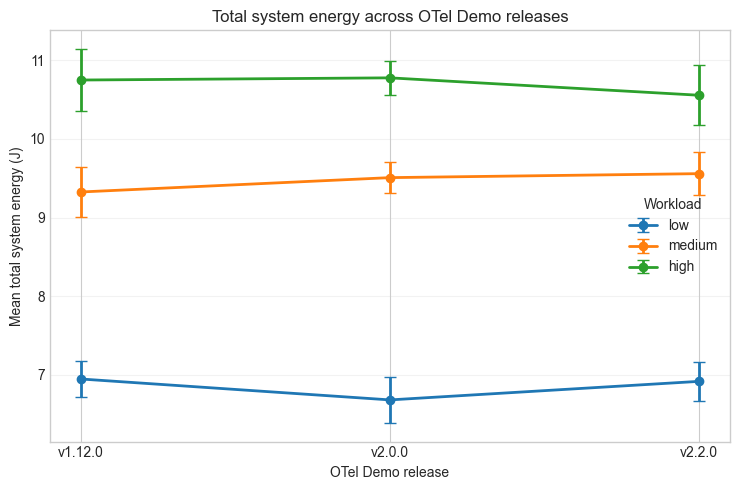

Saved: ../figures/motivation/chart1_total_system_energy_ec2.png
Saved: ../figures/motivation/chart1_total_system_energy_ec2.pdf


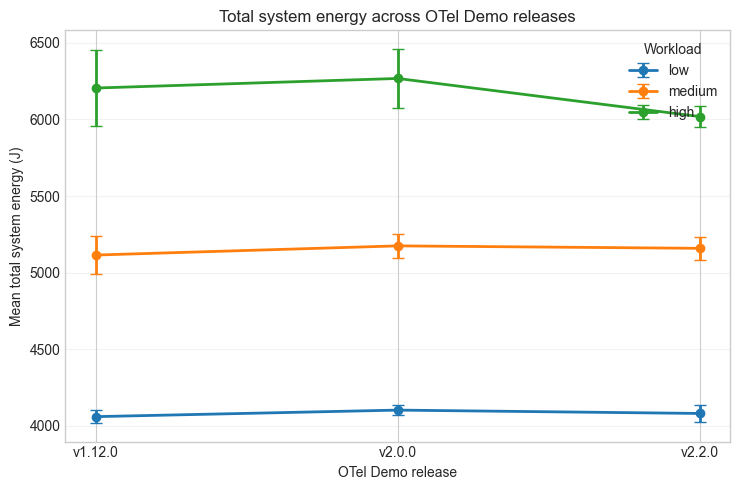

,environment,release,workload_level,mean,std,n,cv
0,workstation,v1.12.0,low,6.947128,0.223569,5,0.032181
1,workstation,v2.0.0,low,6.681227,0.292232,5,0.043739
2,workstation,v2.2.0,low,6.917108,0.252359,5,0.036483
3,workstation,v1.12.0,medium,9.324751,0.315095,5,0.033791
4,workstation,v2.0.0,medium,9.507233,0.197726,5,0.020797
5,workstation,v2.2.0,medium,9.557786,0.272028,5,0.028461
6,workstation,v1.12.0,high,10.748167,0.393097,5,0.036573
7,workstation,v2.0.0,high,10.775781,0.218283,5,0.020257
8,workstation,v2.2.0,high,10.554603,0.379323,5,0.035939
9,ec2,v1.12.0,low,4060.968274,40.765322,5,0.010038


In [9]:
total_energy_summary = prepare_release_summary(runs_df_paper, 'total_system_energy_j')
plot_total_energy_by_release(total_energy_summary)

total_energy_table = total_energy_summary.copy()
total_energy_table['mean'] = total_energy_table['mean'].round(6)
total_energy_table['std'] = total_energy_table['std'].round(6)
total_energy_table['cv'] = total_energy_table['cv'].round(6)
total_energy_table.sort_values(['environment', 'workload_level', 'release']).reset_index(drop=True)

Step 2: Energy per request normalises by useful work, but it remains an end-to-end indicator.

Normalising by requests makes release-level comparisons more meaningful, but still does not explain which services are responsible.

Saved: ../figures/motivation/chart2_energy_per_request_workstation.png
Saved: ../figures/motivation/chart2_energy_per_request_workstation.pdf


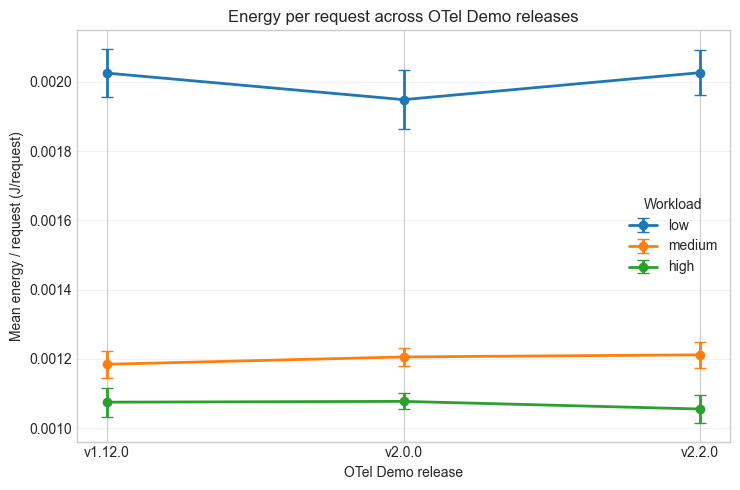

Saved: ../figures/motivation/chart2_energy_per_request_ec2.png
Saved: ../figures/motivation/chart2_energy_per_request_ec2.pdf


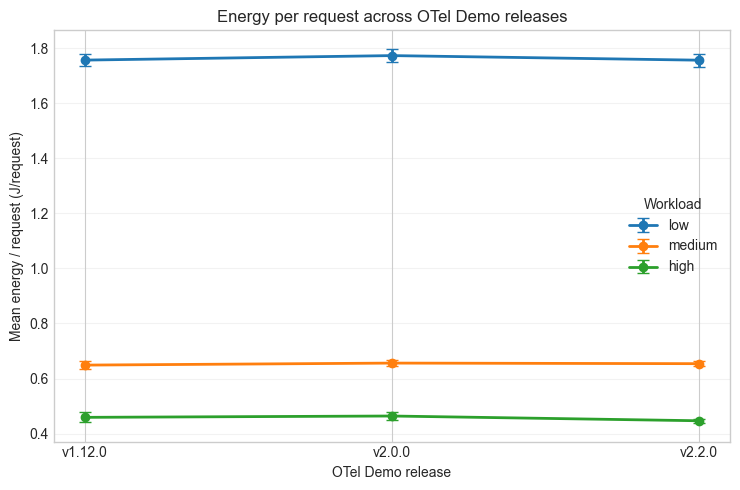

,environment,release,workload_level,mean,std,n,cv
0,workstation,v1.12.0,low,0.002025,0.000069,5,0.034181
1,workstation,v2.0.0,low,0.001948,0.000085,5,0.043656
2,workstation,v2.2.0,low,0.002026,0.000065,5,0.032314
3,workstation,v1.12.0,medium,0.001184,0.000039,5,0.033217
4,workstation,v2.0.0,medium,0.001206,0.000026,5,0.021251
5,workstation,v2.2.0,medium,0.001212,0.000038,5,0.030967
6,workstation,v1.12.0,high,0.001075,0.000042,5,0.038907
7,workstation,v2.0.0,high,0.001077,0.000023,5,0.021412
8,workstation,v2.2.0,high,0.001055,0.000040,5,0.037974
9,ec2,v1.12.0,low,1.756969,0.020435,5,0.011631


In [10]:
energy_per_request_summary = prepare_release_summary(runs_df_paper, 'energy_per_request_j')
plot_energy_per_request_by_release(energy_per_request_summary)

energy_per_request_table = energy_per_request_summary.copy()
energy_per_request_table['mean'] = energy_per_request_table['mean'].round(6)
energy_per_request_table['std'] = energy_per_request_table['std'].round(6)
energy_per_request_table['cv'] = energy_per_request_table['cv'].round(6)
energy_per_request_table.sort_values(['environment', 'workload_level', 'release']).reset_index(drop=True)

Step 3: Service-level attribution is needed to inspect where energy is consumed inside the microservice architecture.

Attribution exposes where energy is distributed inside the application, which end-to-end metrics cannot explain.

Absolute attributed energy table (J), mean +- std:


release,v1.12.0 mean (J),v2.0.0 mean (J),v2.2.0 mean (J),v1.12.0 std (J),v2.0.0 std (J),v2.2.0 std (J)
service,,,,,,
frontend,51.9640,52.0151,52.9453,1.3725,1.3539,1.4960
product-catalog,49.3422,52.2563,54.3663,4.1113,1.1878,2.4916
kafka,4.5410,4.5287,4.4461,0.1854,0.1863,0.0427
load-generator,68.0062,67.7618,67.2418,1.1238,2.3496,1.1699
frontend-proxy,8.4913,8.5086,8.6234,0.2161,0.2150,0.1591
product-reviews,2.3283,2.3438,2.2654,0.1392,0.3412,0.2213


Saved: ../figures/motivation/chart3_service_attribution_workstation_medium_m1_absolute_with_std.png
Saved: ../figures/motivation/chart3_service_attribution_workstation_medium_m1_absolute_with_std.pdf


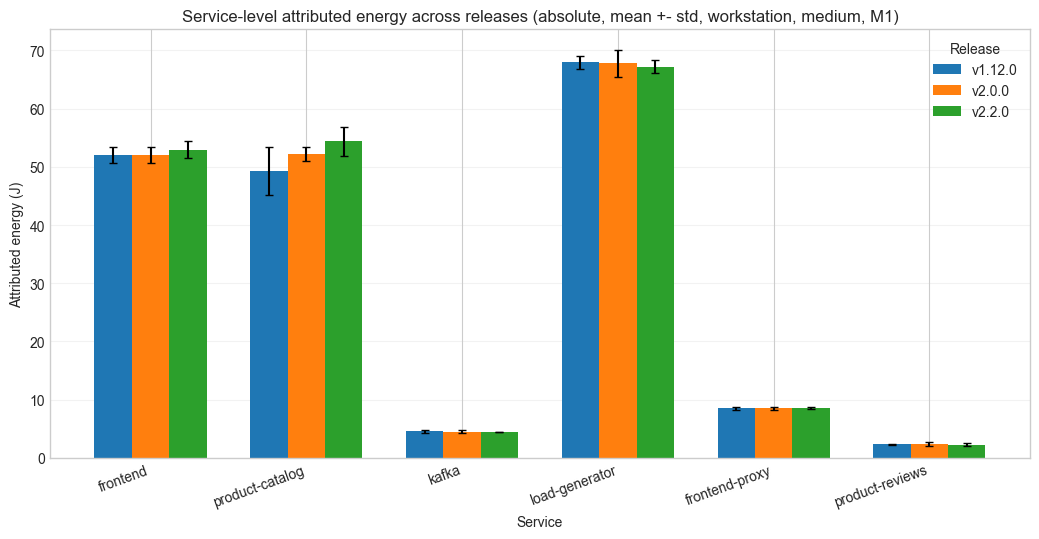

In [13]:
# Absolute attribution chart with uncertainty (mean +- std across 5 runs)
env_sel = 'workstation'
workload_sel = 'medium'
model_sel = 'M1'

service_order = [
    'frontend',
    'product-catalog',
    'kafka',
    'load-generator',
    'frontend-proxy',
    'product-reviews',
]

rows = []

for folder_name, release in RELEASE_MAP_PAPER.items():
    release_dir = RUNS_ROOT / folder_name
    if not release_dir.exists():
        print(f'WARNING: missing release folder for attribution: {release_dir}')
        continue

    matched_experiments = [
        d for d in sorted(release_dir.iterdir())
        if d.is_dir() and environment_from_folder(d.name) == env_sel
    ]

    if not matched_experiments:
        print(f'WARNING: no experiment found for environment={env_sel}, release={release}')
        continue

    for experiment_dir in matched_experiments:
        dashboard_path = experiment_dir / 'runs_comparison.html'
        if not dashboard_path.exists():
            print(f'WARNING: missing dashboard file: {dashboard_path}')
            continue

        payload = extract_json_object_after_marker(
            dashboard_path.read_text(encoding='utf-8'),
            'const data = ',
        )

        workload_payload = (((payload.get('attribution_phase1') or {}).get('workloads') or {}).get(workload_sel) or {})
        model_payload = ((workload_payload.get('models') or {}).get(model_sel) or {})
        services = model_payload.get('services') or {}

        if not services:
            print(
                f'WARNING: missing attribution services for environment={env_sel}, release={release}, '
                f'workload={workload_sel}, model={model_sel}'
            )
            continue

        for service in service_order:
            stats = services.get(service)
            if not stats:
                print(f'WARNING: missing service={service} for release={release}')
                rows.append({
                    'release': release,
                    'service': service,
                    'mean_j': np.nan,
                    'std_j': np.nan,
                })
                continue

            rows.append({
                'release': release,
                'service': service,
                'mean_j': pd.to_numeric(stats.get('mean'), errors='coerce'),
                'std_j': pd.to_numeric(stats.get('std'), errors='coerce'),
            })

if not rows:
    raise RuntimeError('No attribution rows found for absolute chart with uncertainty.')

svc_df = pd.DataFrame(rows)

agg_tbl = (
    svc_df.groupby(['service', 'release'], observed=True)
          .agg(
              mean_j=('mean_j', 'mean'),
              std_j=('std_j', 'mean'),
          )
          .reset_index()
          .pivot(index='service', columns='release', values=['mean_j', 'std_j'])
 )

mean_tbl = agg_tbl['mean_j'].reindex(service_order).reindex(columns=RELEASE_ORDER_PAPER)
std_tbl = agg_tbl['std_j'].reindex(service_order).reindex(columns=RELEASE_ORDER_PAPER)

for svc in service_order:
    if svc not in mean_tbl.index:
        print(f'WARNING: service missing in plotted table: {svc}')
        continue
    for rel in RELEASE_ORDER_PAPER:
        if pd.isna(mean_tbl.loc[svc, rel]):
            print(f'WARNING: missing mean attribution for service={svc}, release={rel}')
        if pd.isna(std_tbl.loc[svc, rel]):
            print(f'WARNING: missing std attribution for service={svc}, release={rel}')

print('Absolute attributed energy table (J), mean +- std:')
display(
    pd.concat([
        mean_tbl.add_suffix(' mean (J)'),
        std_tbl.add_suffix(' std (J)'),
    ], axis=1).round(4)
 )

x = np.arange(len(service_order))
width = 0.24
fig, ax = plt.subplots(figsize=(10.5, 5.5))

for idx, rel in enumerate(RELEASE_ORDER_PAPER):
    offset = (idx - 1) * width
    y = mean_tbl[rel].fillna(0.0).to_numpy()
    yerr = std_tbl[rel].fillna(0.0).to_numpy()
    ax.bar(
        x + offset,
        y,
        width=width,
        yerr=yerr,
        capsize=3,
        label=rel,
    )

ax.set_xticks(x)
ax.set_xticklabels(service_order, rotation=20, ha='right')
ax.set_xlabel('Service')
ax.set_ylabel('Attributed energy (J)')
ax.set_title('Service-level attributed energy across releases (absolute, mean +- std, workstation, medium, M1)')
ax.legend(title='Release')
ax.grid(True, axis='y', alpha=0.25)

fig.tight_layout()
png_path = FIGURES_DIR / 'chart3_service_attribution_workstation_medium_m1_absolute_with_std.png'
pdf_path = FIGURES_DIR / 'chart3_service_attribution_workstation_medium_m1_absolute_with_std.pdf'
fig.savefig(png_path, dpi=300, bbox_inches='tight')
fig.savefig(pdf_path, bbox_inches='tight')
print(f'Saved: {png_path}')
print(f'Saved: {pdf_path}')
plt.show()

Step 4: Fixed-utilisation normalisation is required to compare releases or applications at comparable operating points.

TODO: This notebook currently uses release-level aggregate and attribution summaries from runs_comparison payloads, not timestamped per-sample telemetry. To build the fixed-utilisation plot, add:

- timestamped CPU utilisation
- timestamped energy or power
- timestamped request count / throughput
- filtering logic around selected utilisation percentile, e.g. 80th percentile CPU or memory utilisation.